This script is coded for visualize evaluation data with raincloud plot by ptitprince package

In [1]:
import os
# import sys
import pandas as pd
import matplotlib.pyplot as plt   
from matplotlib.legend_handler import HandlerTuple
from matplotlib.lines import Line2D
import ptitprince as pt

# I. Load data

In [ ]:
# Define the path to the data folders relative to the notebook
current_dir = os.getcwd()  # Get the current working directory

# Define paths for data loading
folder_path = os.path.join(current_dir, '../data/')

# Define path for saving figures
folder_path_figure = os.path.join(current_dir, '../figs/')

# Define the file name (same for both folders)
file_strict = 'data_choice_evaluation_strict.csv'
file_not_strict = 'data_choice_evaluation_not_strict.csv'

# Load the CSV file
df_strict = pd.read_csv(os.path.join(folder_path, file_strict))
df_less_strict = pd.read_csv(os.path.join(folder_path, file_not_strict))

In [3]:
# ouptut_dir
output_path = os.path.join(current_dir, '../results')

In [4]:
df_strict

,prolific_id,frame,question,main,follow_up,choice,evaluation
0,6100055d33f16a3c21e34bc5,loss,Disease,True,NaN,1,22
1,6100055d33f16a3c21e34bc5,loss,Unemployment,True,NaN,0,62
2,6100055d33f16a3c21e34bc5,loss,Painting,True,NaN,1,73
3,6100055d33f16a3c21e34bc5,loss,Virus,True,NaN,1,40
4,5fecefec0b1a44a2fce2197b,loss,Disease,True,NaN,2,30
...,...,...,...,...,...,...,...
2134,67f5c7cd44d9d8b9855c14a1,gain,Virus,True,NaN,0,99
2135,67360451448620a00803e7f5,gain,Disease,True,NaN,0,61
2136,67360451448620a00803e7f5,gain,Unemployment,True,NaN,1,77
2137,67360451448620a00803e7f5,gain,Painting,True,NaN,0,70


# II. Function

In [5]:
# group by frame, add dash line between frames
def create_raincloud_plot(data, choice_format):
    """
    Create raincloud plots for evaluation data, grouped by frame
    
    Parameters:
    data (DataFrame): Input dataframe with evaluation data
    choice_format (str): 'main' for ternary choice or 'follow_up' for binary choice
    """
    # Create figure with 1 row and 3 columns
    fig, axes = plt.subplots(3, 1, figsize=(15, 15), sharey=True)
    labelsize = 24
    titlesize = 30
    ticklabelsize = 20
    legendsize = 20
    
    # Define palette and configuration based on choice format
    if choice_format == "main":
        # Reorder palette: gain choices first, then loss choices
        palette = ["#a6cee3", "#fdbf6f", "#D3D3D3", "#1f78b4", "#ff7f00", "#505050"]
        choice_names = {0: 'Sure', 1: 'Risky', 2: 'Neutral'}
        x_ticks = [1, 4]  # Center of each frame group
        separator_x = 2.5  # Line between position 2 and 3
    else:  # follow_up
        palette = ["#a6cee3", "#fdbf6f", "#1f78b4", "#ff7f00"]
        choice_names = {0: 'Sure', 1: 'Risky'}
        x_ticks = [0.5, 2.5]  # Center of each frame group
        separator_x = 1.5  # Line between position 1 and 2
    
    # Loop through each question and create a raincloud plot
    for i, question in enumerate(["Disease", "Painting", "Virus"]):
        # Filter the dataframe for the current question and choice format
        df = data[(data[choice_format] == True) & (data['question'] == question)].copy()
        
        # Create choice type mapping
        df['choice_type'] = df['choice'].map(choice_names)
        
        # NEW: Create frame_choice_group (frame first, then choice)
        df['frame_choice_group'] = df['frame'] + "_" + df['choice_type']
        
        # NEW: Sort by frame first, then by choice within each frame
        df['order'] = (df['frame'] == 'loss').astype(int) * len(choice_names) + df['choice'].astype(int)
        df = df.sort_values('order')
        
        # Generate raincloud plot
        pt.RainCloud(x="frame_choice_group", y="evaluation", data=df, 
                    palette=palette, bw=0.2, width_viol=0.5, ax=axes[i], orient="v",
                    point_size=4 if choice_format == "main" else 5,
                    jitter=1, alpha=0.7)
        
        # Add vertical dashed line to separate frame groups
        axes[i].axvline(x=separator_x, color='gray', linestyle='--', 
                        linewidth=2, alpha=0.7, zorder=0)
        
        # Enhance visualization
        axes[i].yaxis.grid(True, linestyle='-', alpha=0.7)
        if i == 1:
            axes[i].set_ylabel("Confidence Evaluation", fontsize=labelsize)
        else:
            axes[i].set_ylabel("")
        if question == "Virus":
            axes[i].set_title("Computer Virus", fontsize=titlesize)
        elif question == "Painting":
            axes[i].set_title("Damaged Painting", fontsize=titlesize)
        else:
            axes[i].set_title(question, fontsize=titlesize)
        
        # NEW: Set x-ticks and labels for frames
        axes[i].set_xticks(x_ticks)
        axes[i].set_xticklabels(["Gain", "Loss"], fontsize=ticklabelsize)
        
        if i == 2:
            axes[i].set_xlabel("Frame", fontsize=labelsize)
        else:
            axes[i].set_xlabel("")
        
        # Set y-ticks
        axes[i].tick_params(axis='y', labelsize=ticklabelsize)
        
        # Add sample size for each frame_choice_group
        group_counts = df.groupby('frame_choice_group').size().to_dict()
        group_order = df['frame_choice_group'].unique()
        
        # Determine x positions based on choice format
        if choice_format == "main":
            # For main task: 6 groups (gain_Sure, gain_Risky, gain_Neutral, loss_Sure, loss_Risky, loss_Neutral)
            x_positions = [0, 1, 2, 3, 4, 5]
        else:
            # For follow_up: 4 groups (gain_Sure, gain_Risky, loss_Sure, loss_Risky)
            x_positions = [0, 1, 2, 3]
            
        # Match the displayed groups to their positions
        for idx, group in enumerate(group_order):
            count = group_counts.get(group, 0)
            # Position the labels right above the x-axis
            axes[i].text(x_positions[idx], axes[i].get_ylim()[0]-5, 
                        f"n={count}", ha='center', va='bottom', 
                        fontsize=ticklabelsize, color='black',
                        clip_on=False)

    # NEW: Define legend handles for choices (not frames)
    if choice_format == "main":
        # Create handles for each choice type
        sure_handle = Line2D([0], [0], color="#a6cee3", lw=4)
        risky_handle = Line2D([0], [0], color="#fdbf6f", lw=4)
        neutral_handle = Line2D([0], [0], color="#D3D3D3", lw=4)
        
        axes[0].legend(
            handles=[sure_handle, risky_handle, neutral_handle],
            labels=["Sure", "Risky", "Neutral"],
            loc='upper left',
            bbox_to_anchor=(1.02, 1),
            fontsize=legendsize,
            frameon=False,
        )
    else:
        sure_handle = Line2D([0], [0], color="#a6cee3", lw=4)
        risky_handle = Line2D([0], [0], color="#fdbf6f", lw=4)
        
        axes[0].legend(
            handles=[sure_handle, risky_handle],
            labels=["Sure", "Risky"],
            loc='upper left',
            bbox_to_anchor=(1.02, 1),
            fontsize=legendsize,
            frameon=False,
        )
    
    # set ylim for all axes
    for ax in axes:
        ax.set_ylim(-10, 110)
        
    # Adjust bottom margin to make room for sample size labels
    plt.subplots_adjust(bottom=0.15)
    plt.tight_layout()
    return fig

# II. Run visualization

## 1. Strict dataset

### 1.1 Ternary choice

In [6]:
data = df_strict.copy()

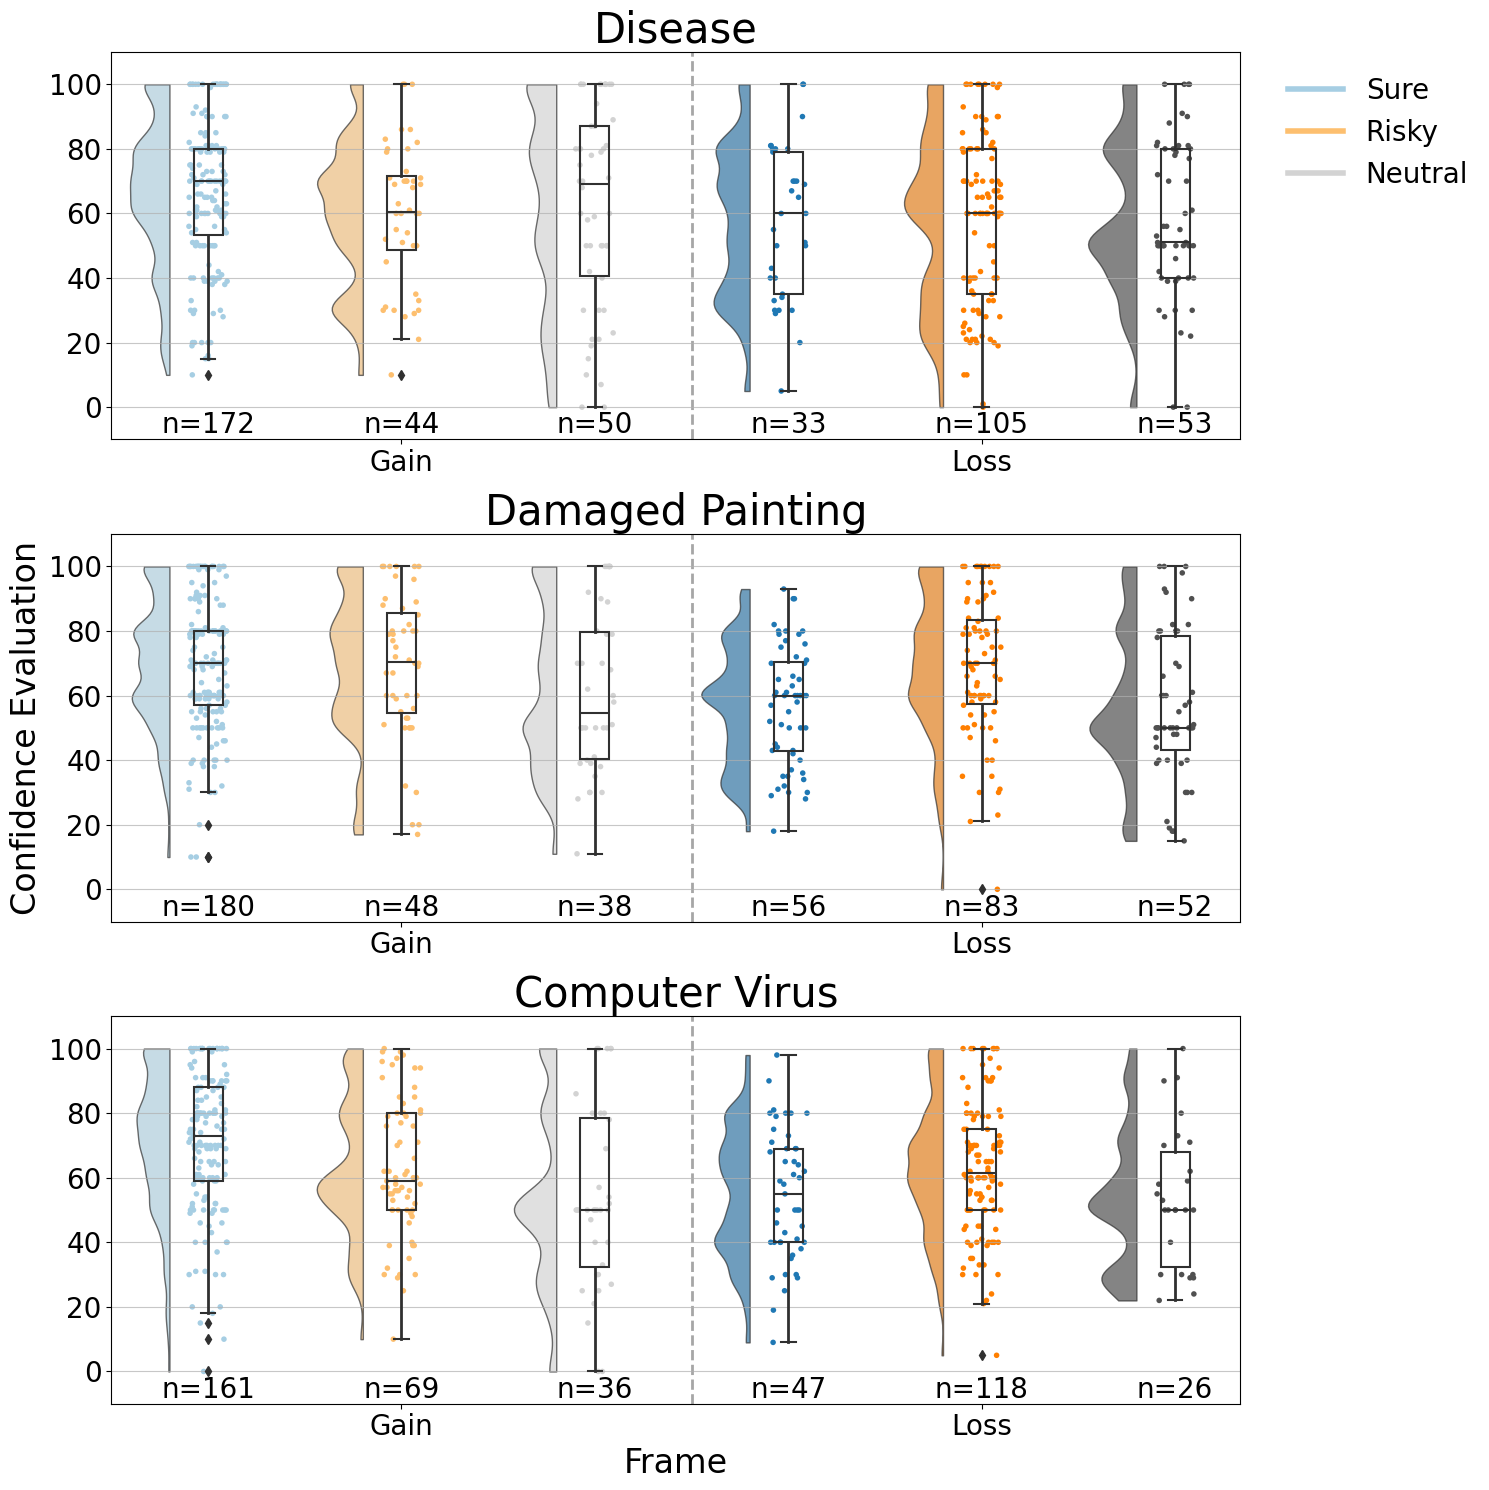

In [7]:

fig = create_raincloud_plot(data, choice_format="main")


In [8]:
# save the figure
fig.savefig(os.path.join(output_path, 'evaluation_distribution_raincloud_strict_ternary.png'), bbox_inches='tight', dpi=300)

### 1.2 Binary Choice

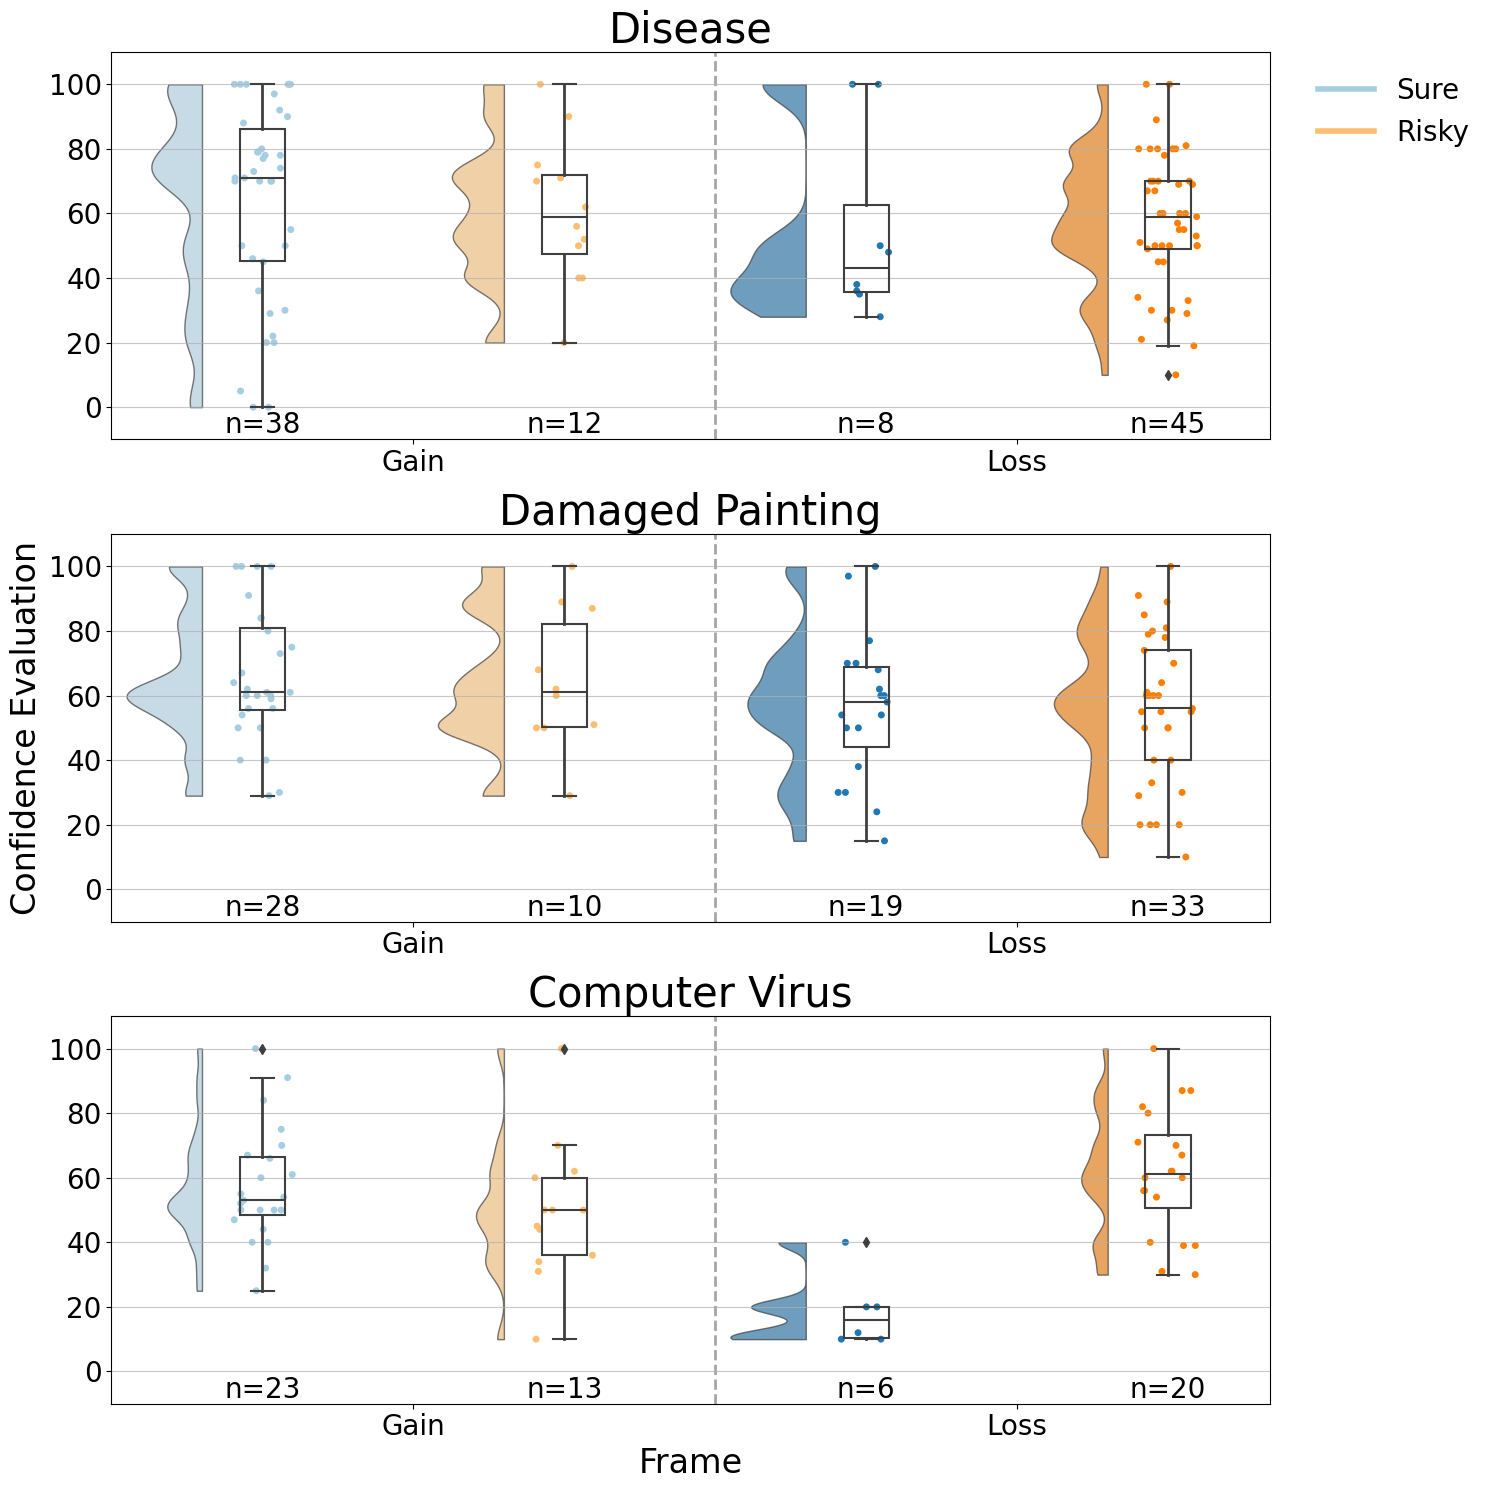

In [9]:
fig = create_raincloud_plot(data, choice_format="follow_up")


In [10]:
# save the figure
fig.savefig(os.path.join(output_path, 'evaluation_distribution_raincloud_strict_binary.png'), bbox_inches='tight', dpi=300)

## 2. Less Strict Dataset

### 2.1 Ternary choice

In [11]:
data = df_less_strict.copy()

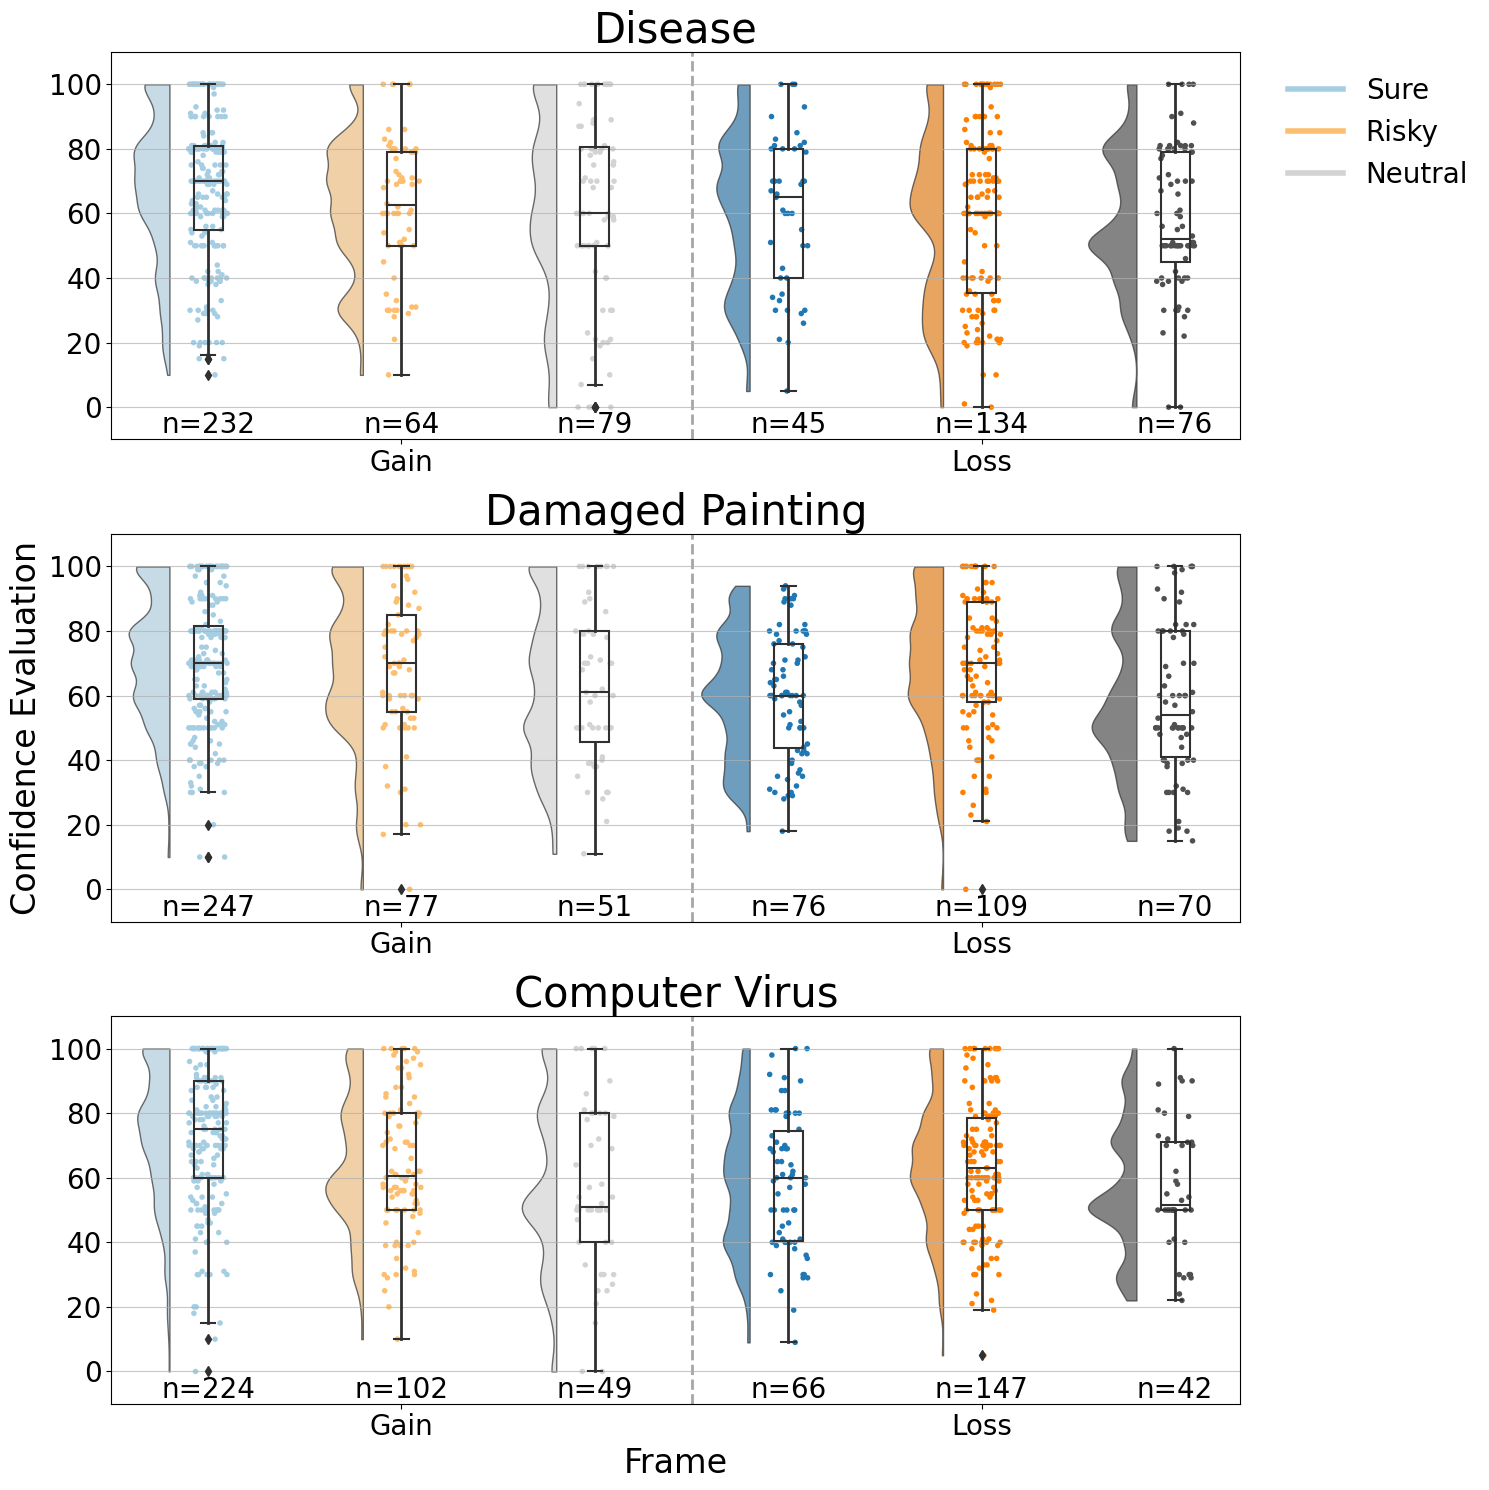

In [12]:
fig = create_raincloud_plot(data, choice_format="main")
# save the figure
fig.savefig(os.path.join(output_path, 'evaluation_distribution_raincloud_less_strict_ternary.png'), bbox_inches='tight', dpi=300)

### 1.2 Binary Choice

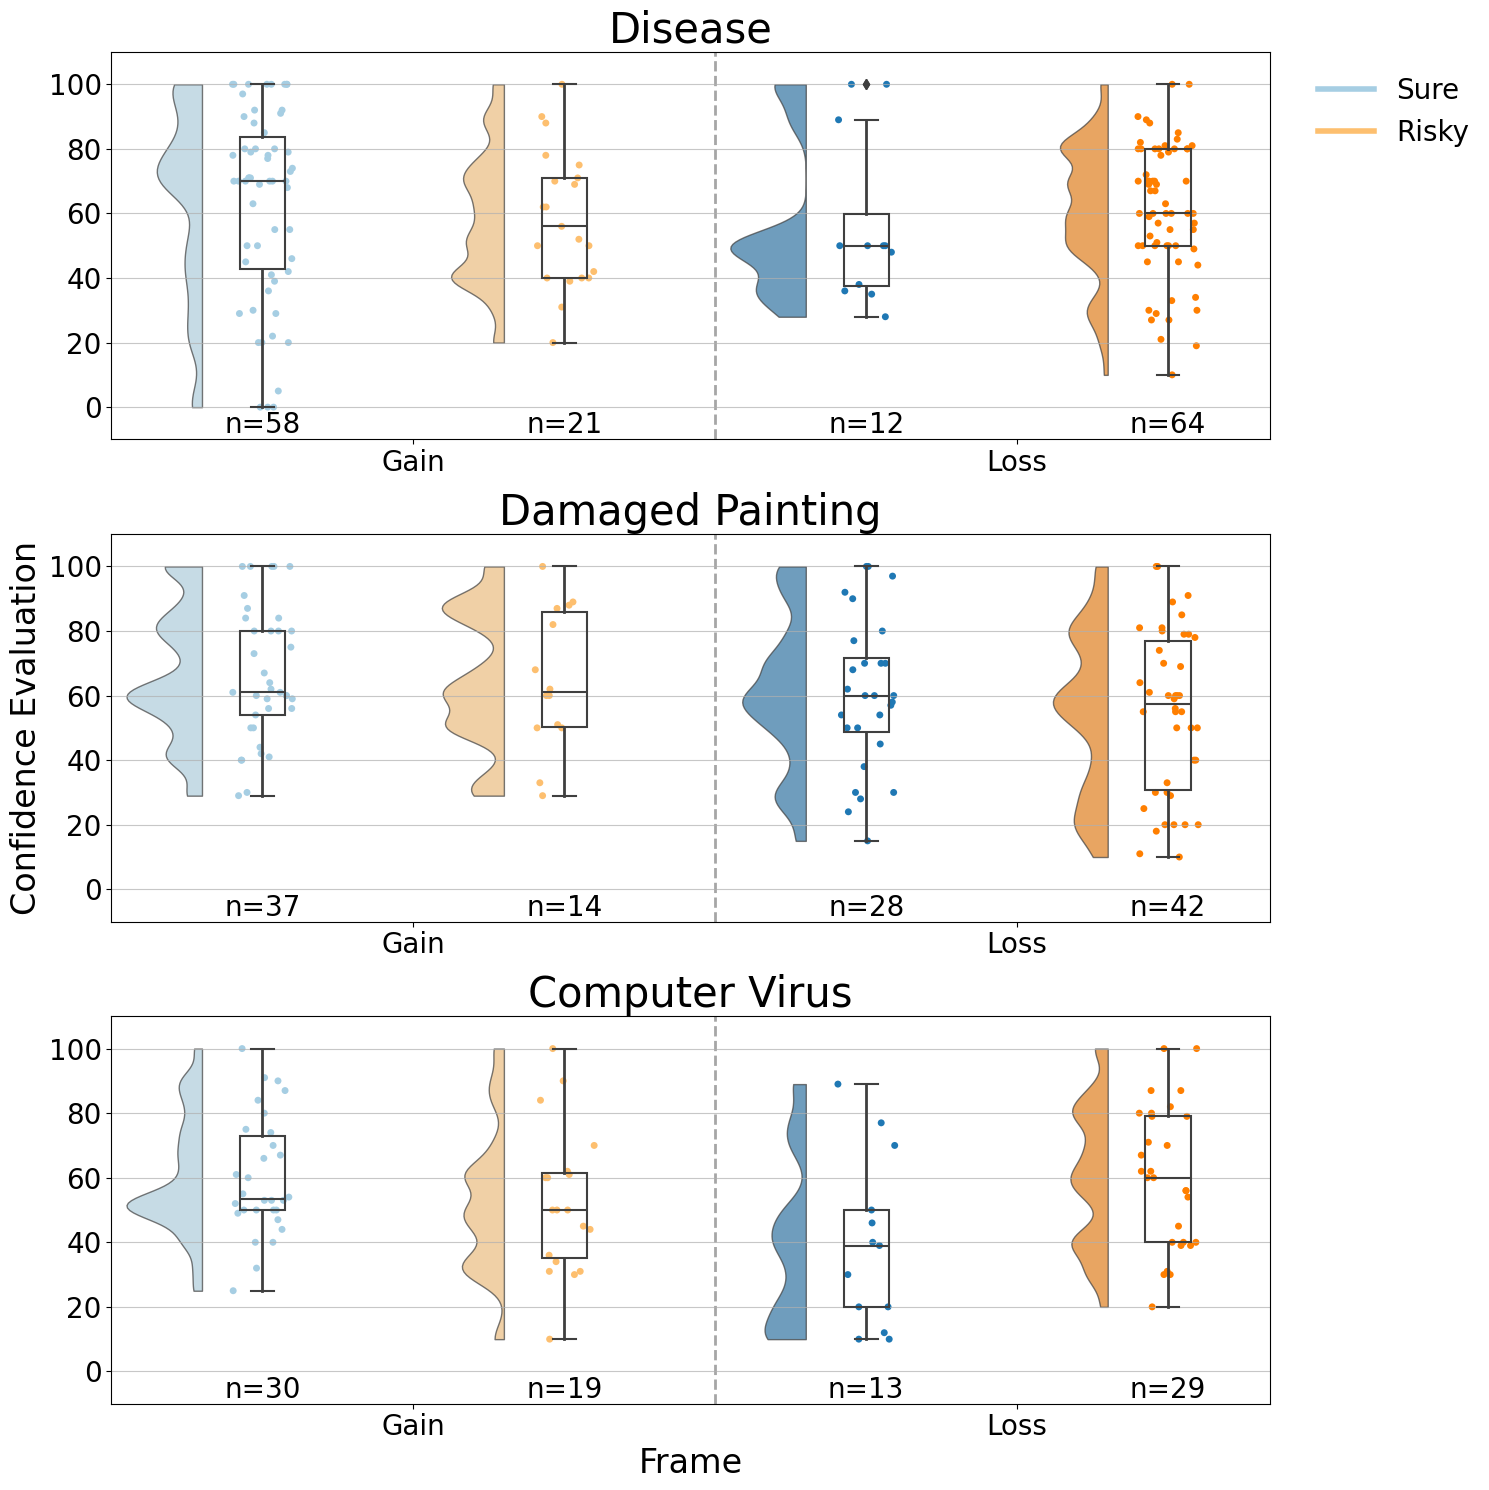

In [13]:
fig = create_raincloud_plot(data, choice_format="follow_up")
# save the figure
fig.savefig(os.path.join(output_path, 'evaluation_distribution_raincloud_less_strict_binary.png'), bbox_inches='tight', dpi=300)